In [645]:
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost
from scipy import stats
from scipy.special import binom
from scipy.optimize import fsolve
import pandas as pd
from scipy.stats import chi2

In [307]:

def multiple_formatter(denominator=2, number=np.pi, latex='\pi'):
    def gcd(a, b):
        while b:
            a, b = b, a%b
        return a
    def _multiple_formatter(x, pos):
        den = denominator
        num = int(np.rint(den*x/number))
        com = gcd(num,den)
        (num,den) = (int(num/com),int(den/com))
        if den==1:
            if num==0:
                return r'$0$'
            if num==1:
                return r'$%s$'%latex
            elif num==-1:
                return r'$-%s$'%latex
            else:
                return r'$%s%s$'%(num,latex)
        else:
            if num==1:
                return r'$\frac{%s}{%s}$'%(latex,den)
            elif num==-1:
                return r'$\frac{-%s}{%s}$'%(latex,den)
            else:
                return r'$\frac{%s%s}{%s}$'%(num,latex,den)
    return _multiple_formatter

class Multiple:
    def __init__(self, denominator=2, number=np.pi, latex='\pi'):
        self.denominator = denominator
        self.number = number
        self.latex = latex


    def locator(self):
        return plt.MultipleLocator(self.number / self.denominator)


    def formatter(self):
        return plt.FuncFormatter(multiple_formatter(self.denominator, self.number, self.latex))

# 1 Distributions and probabilites


## 1.1.1 Binomial between days

In [2]:
# # get binomial function from scipy.stats
# binom = stats.binom
# # plot binomial distribution for n=10 and p= 1/6
# n = 10
# p = 1/6
# x = np.arange(0, n+1)
# pmf = binom.pmf(x, n, p)
# plt.bar(x, pmf)
# plt.xlabel('Number of successes')
# plt.ylabel('Probability')
# plt.title('Binomial Distribution (n=10, p=1/6)')
# plt.show()

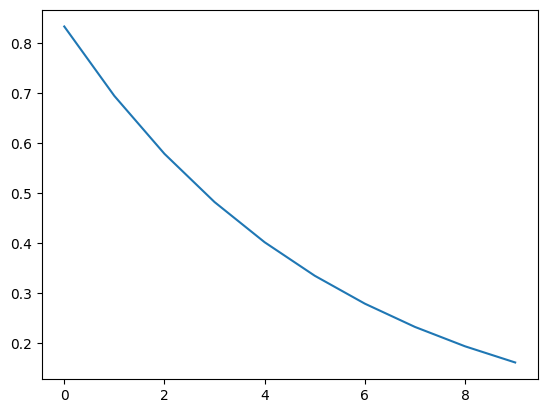

In [3]:
# Calulating the chance to go n days without  push-ups
# n being offset by 1 compared to a normal binormial distribution because we count the starting day as well

#geometric distribution: P(X=k) = (1-p)^k * p
def prob_pushups(n, p):
    return p * (1 - p) ** n

def prob_no_pushups(n, p):
    return (1 - p) ** (n+1)

plt.plot(np.arange(0, 10), prob_no_pushups(np.arange(0, 10), 1/6))
# plt.yscale('log')




In [4]:
# simulating data

n_days = 10000
p_pushup = 1/6

data = np.zeros(n_days)
for day in range(n_days):
    while True:
        if np.random.rand() < p_pushup:
            break
        data[day] += 1


In [5]:
# normalisation

# integral of prob_no_pushups from 0 to inf is 1/p
# so we need to multiply by p to normalise

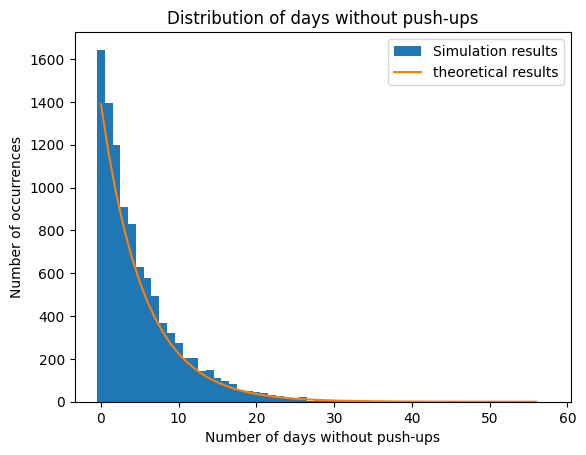

In [6]:
plt.hist(data, bins=np.arange(-0.5, np.max(data)+1.5), label= 'Simulation results')
plt.plot(np.arange(0, np.max(data)), n_days/6*prob_no_pushups(np.arange(0, np.max(data)), 1/6), label='theoretical results')
plt.legend()
plt.title('Distribution of days without push-ups')
plt.xlabel('Number of days without push-ups')
plt.ylabel('Number of occurrences')
plt.show()


In [7]:
# minuit fit to get chi2 between data and model
def chi2_pushups(p):
    expected = n_days * p * (1 - p) ** (np.arange(0, np.max(data)+1))
    observed, _ = np.histogram(data, bins=np.arange(-0.5, np.max(data)+1.5))
    chi2 = np.sum((observed - expected) ** 2 / expected)
    return chi2

print(chi2_pushups(1/6))


70.31930008943647


## 1.1.2 Distribution of pushups over 10 days


In [8]:
# probability calculated mean:
p_pushup = 1/6
p_pushup**2*10*120

33.333333333333336

C:\Users\adamo\AppData\Local\Temp\ipykernel_21948\10664451.py:17: RuntimeWarning: invalid value encountered in scalar multiply
  p_amount = binom(j_max, j) * (1/6)**j * (5/6)**(j_max - j)


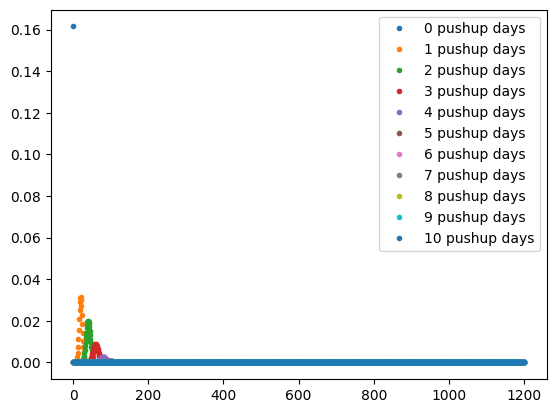

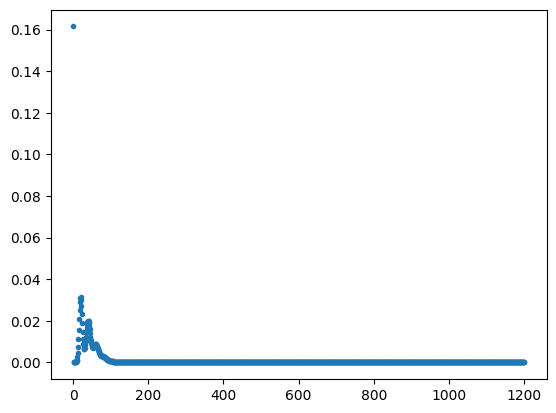

Mean: 33.333333333334856
Median: 31


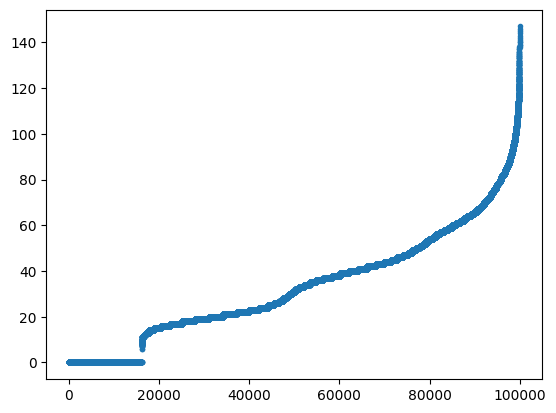

median of std estimator: 31.0
mean of std estimator: 33.29702167690799
standard deviation: 24.089136564161613


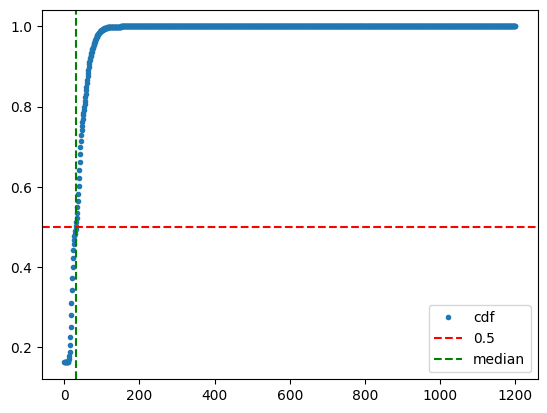

In [9]:
# First what happens on one day
# then what happens over n days

#For one day the 1/6 for pushups, and in case of pushups there is a cumulative 1/6 to add a pushup 120 times.
# This is the probability mass function of a binomial distribution with n=120 and p=1/6.

pushup_amounts = np.zeros((1201,11))
k = []

for i in range(11):
    # do the weighted chance for k pushup days
    k_day = binom(10, i) * (1/6)**i * (5/6)**(10 - i)
    k += [k_day]
    j_max = 120 * i
    for j in range(j_max + 1):
        # for that amount of pushup days, calculate the chance to have j pushups in total
        p_amount = binom(j_max, j) * (1/6)**j * (5/6)**(j_max - j)
        if not p_amount < 1 and not p_amount > -1 or p_amount == float('inf') or p_amount == float('-inf'):
            p_amount = 0
        pushup_amounts[j, i] += k_day * p_amount

# print(len(pushup_amounts))
# print(np.median(pushup_amounts))
# print(pushup_amounts)
# plt.plot(pushup_amounts, '.')
for i in range(11):
    plt.plot(pushup_amounts[:, i], '.', label=f'{i} pushup days')
plt.legend()
plt.show()
# print(pushup_amounts)
# print(np.sum(pushup_amounts, axis=0))

pushup_amounts_total = np.sum(pushup_amounts, axis=1)
plt.plot(pushup_amounts_total, '.', label='total')
plt.show()
pushup_array = np.arange(0, len(pushup_amounts_total))
# testing if the mean is as expected
mean = np.sum(pushup_array * pushup_amounts_total) / np.sum(pushup_amounts_total)
print(f'Mean: {mean}')

# calculating the median as where the cumulative distribution reaches 0.5
counter = 0
for  i in range(len(pushup_amounts_total)):
    counter += pushup_amounts_total[i]
    if counter >= 0.5:
        median = i
        break

print(f'Median: {median}')

std_estimator = []
for i in range(len(pushup_amounts_total)):
    std_estimator += [np.ones(int(pushup_amounts_total[i]*100000)) * i]
std_estimator = np.concatenate(std_estimator)
plt.plot(std_estimator, '.', label='std estimator')
plt.show()
print('median of std estimator:', np.median(std_estimator))
print('mean of std estimator:', np.mean(std_estimator))
print(f'standard deviation: {np.std(std_estimator)}')
# plot the cdf
cdf = np.cumsum(pushup_amounts_total) / np.sum(pushup_amounts_total)
plt.plot(cdf, '.', label='cdf')
plt.axhline(0.5, color='r', linestyle='--', label='0.5')
plt.axvline(median, color='g', linestyle='--', label='median')
plt.legend()
plt.show()

median of simulation: 31.0
mean of simulation: 33.387444
standard deviation: 24.15707058289278


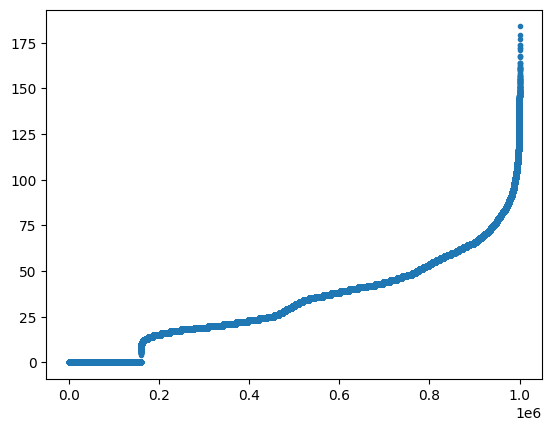

In [10]:
def pushup_10_day_generetor():
    p = 1/6
    n_pushups = 0
    for i in range(10):
        if np.random.rand() < p:
            # number of pushups done that day
            n_pushups += np.random.binomial(120, p)
    return n_pushups

pushups_simulated = np.zeros(int(1e6))

for i in range(int(1e6)):
    pushups_simulated[i] = pushup_10_day_generetor()

plt.plot(np.sort(pushups_simulated), '.', label='simulated pushups over 10 days')

print('median of simulation:', np.median(pushups_simulated))
print('mean of simulation:', np.mean(pushups_simulated))
print(f'standard deviation: {np.std(pushups_simulated)}')

## 1.2 the alignment of pyramids


In [11]:
# simply just calculating the probabilities as the two ratios?

span = 6
limit_1 = 90
limit_2 = 180

p_1 = span/limit_1
p_2 = span/limit_2

print(p_1, p_2)

0.06666666666666667 0.03333333333333333


# 2 Error propegation

## 2.1 Water on earth
Water on Earth $\bigoplus$ has a Deuterium to Hydrogen ratio of  $r_{\bigoplus} = (149 \pm 3) \times 10^{-6}$. 

The hydrogen of the proto-solar system $(\bigodot)$ has a ratio of $r_{\bigodot} = (25 \pm 5) \times 10^{-6}$, while that of comets $(C)$ have been measured to be $r_C = (309 \pm 20)\times 10^{-6}$.
-  From these numbers, what fraction of water on Earth do you estimate come from the original proto-solar system, and what fraction do you attribute to comets?


In [12]:


r_earth = 149e-6  
r_earth_err = 3e-6
r_solar = 25e-6
r_solar_err = 5e-6
r_comets = 309e-6
r_comets_err = 20e-6

# Define the LHS equations
def equations(vars):
    a, b = vars
    eq1 = a + b - 1  # a + b = 1
    eq2 = a * r_solar + b * r_comets - r_earth  # r_earth = a * r_solar + b * r_comets
    return [eq1, eq2]

# RHS values
initial_guess = [0, 0]

# Solve the system
solution = fsolve(equations, initial_guess)
a, b = solution
# propagate errors
a_err = np.sqrt((r_earth_err / (r_solar - r_comets))**2 + (r_solar_err * (r_earth - r_comets) / (r_solar - r_comets)**2)**2 + (r_comets_err * (r_solar - r_earth) / (r_solar - r_comets)**2)**2)
b_err = a_err  # since b = 1 - a, the errors are the same

print(f"Fraction from proto-solar system: {a:.2f} ± {a_err:.2f}")
print(f"Fraction from comets:             {b:.2f} ± {b_err:.2f}")
print(f"Check: {a * r_solar + b * r_comets} (should equal {r_earth})")

# print(f"Error in fraction from proto-solar system: {a_err}")
# print(f"Error in fraction from comets: {b_err}")


Fraction from proto-solar system: 0.56 ± 0.03
Fraction from comets:             0.44 ± 0.03
Check: 0.000149 (should equal 0.000149)


## geiger counter

In [13]:
t     = 98.4
t_err = 3.7
N = 1971
N_err = np.sqrt(N)

r = N / t
r_err = np.sqrt( (N_err / t)**2 + (N * t_err / t**2)**2 )

print(f'Rate: {r:.2f} ± {r_err:.2f} counts per unit time')
print(r_err/r)

Rate: 20.03 ± 0.88 counts per unit time
0.04383193984763767


In [14]:
def equations(a):
    eq1 = 0.025**2*a**2 - a/r - t_err**2
    return eq1

solution = fsolve(equations, 100)
print(solution)

[193.23338677]


0.04383193984763766


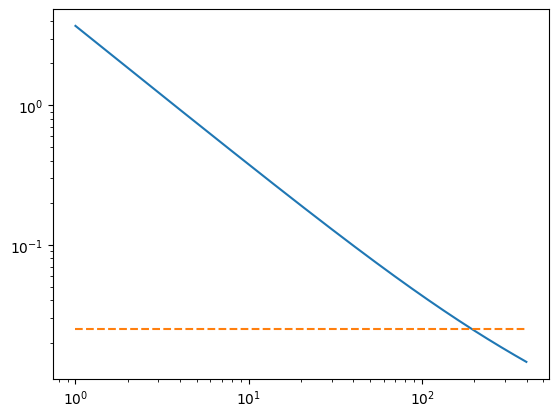

In [15]:
def funct(a):
    return np.sqrt(1/(a*r) + (t_err/a)**2)

print(funct(t))
x_start, x_end = 1, 400
plt.plot(np.arange(x_start, x_end), funct(np.arange(x_start, x_end)))
plt.plot(np.arange(x_start, x_end), 0.025*np.ones(len(np.arange(x_start, x_end))), '--')
plt.yscale('log')
plt.xscale('log')

## Pylons
The file www.nbi.dk/„petersen/data PylonPositions.csv contains position mea-
surements (both with and without uncertainties) of four pylons for a bridge.


### Using measurements without uncertainty, determine the four pylon positions.

In [16]:
dataframe = pd.read_csv('data_PylonPositions.csv', header=0)
Ppos, Ppos_unc = dataframe.values.T
dataframe

,# Position,Uncertainty
0,49.376,-1.000
1,51.980,-1.000
2,57.190,-1.000
3,53.239,-1.000
4,39.348,-1.000
...,...,...
115,172.586,0.672
116,173.253,1.118
117,173.993,0.722
118,172.370,0.889


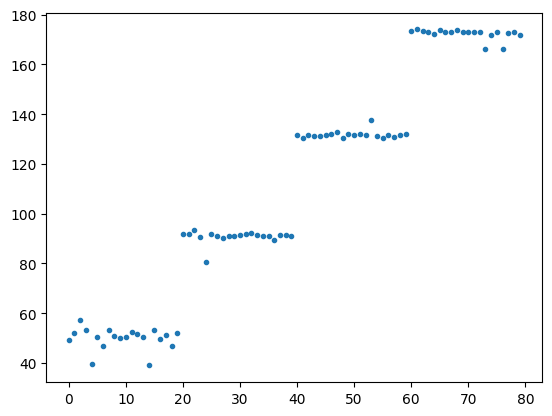

In [17]:
#get dataframe rows where Uncertainty is -1
# print(Ppos[Ppos_unc == -1])
pylon_no_unc = Ppos[Ppos_unc == -1]
x_min, x_max = 30, 180
bins = 150
Bins = np.linspace(x_min, x_max, bins)
counts, bin_edges = np.histogram(pylon_no_unc, bins=Bins)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

def fit_4_gauss(x, A1, mu1, sigma1, A2, mu2, sigma2, A3, mu3, sigma3, A4, mu4, sigma4):
    gauss1 = A1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2)
    gauss2 = A2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2)
    gauss3 = A3 * np.exp(-0.5 * ((x - mu3) / sigma3) ** 2)
    gauss4 = A4 * np.exp(-0.5 * ((x - mu4) / sigma4) ** 2)
    return gauss1 + gauss2 + gauss3 + gauss4

mask = counts > 0
x_fit = bin_centers[mask]
y_fit = counts[mask]
y_err = np.sqrt(y_fit)

plt.plot(np.arange(len(pylon_no_unc)), pylon_no_unc, '.')

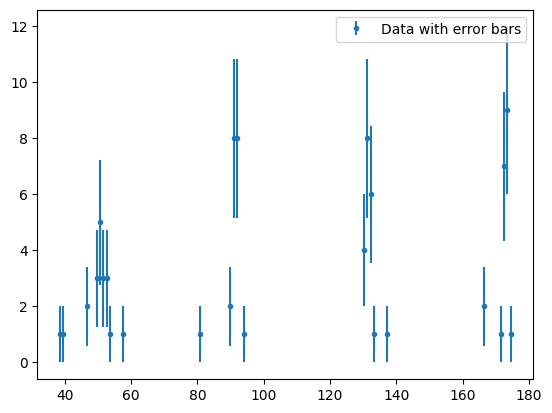

In [18]:
plt.errorbar(x_fit, y_fit, yerr=y_err, fmt='.', label='Data with error bars')
plt.legend()
# plt.xlim(30,60)

In [19]:
Minuit.print_level = 1    

cfit = cost.LeastSquares(x_fit, y_fit, y_err, fit_4_gauss)

m = Minuit(cfit, A1=3 , mu1=50 , sigma1=1.2,
                 A2=9 , mu2=91 , sigma2=1,
                 A3=7,  mu3=131, sigma3=1,
                 A4=1,  mu4=170, sigma4=1)
m.migrad()

if (not m.fmin.is_valid) :
    print("  WARNING: The ChiSquare fit DID NOT converge!!! ")    


[49.84120401723322, 91.64403613973558, 131.32811406212267, 173.01270304043908]
[2.798171337569426, 1.0581106007892065, 0.9245338281474274, 0.6901962230272953]


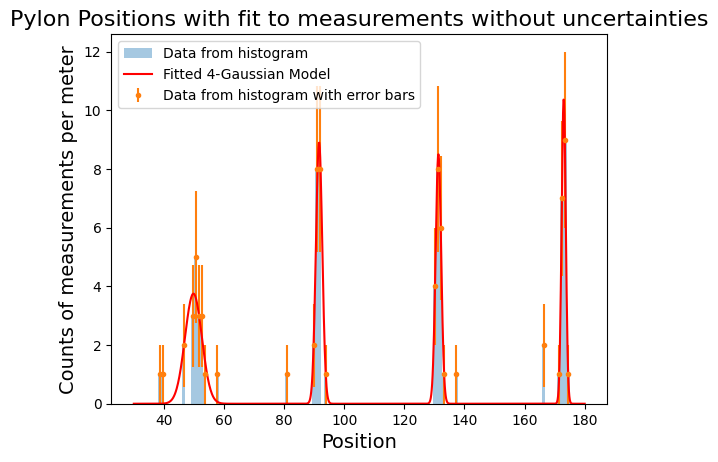

In [20]:
A = m.values[::3]
mu = m.values[1::3]
sigma = m.values[2::3]
print(mu)
print(sigma)

xx = np.linspace(x_min, x_max, 1000)

plt.hist(pylon_no_unc, bins=Bins, alpha=0.4, label='Data from histogram')
plt.errorbar(x_fit, y_fit, yerr=y_err, fmt='.', label='Data from histogram with error bars')
plt.plot(xx, fit_4_gauss(xx, *m.values), label='Fitted 4-Gaussian Model', color='red')
plt.legend()
plt.title('Pylon Positions with fit to measurements without uncertainties', fontsize=16)
plt.xlabel('Position', fontsize=14)
plt.ylabel('Counts of measurements per meter', fontsize=14)
plt.show()

In [21]:
peak1 = pylon_no_unc[(pylon_no_unc < 70)]
peak2 = pylon_no_unc[(pylon_no_unc > 70) & (pylon_no_unc < 110)]
peak3 = pylon_no_unc[(pylon_no_unc > 110) & (pylon_no_unc < 150)]
peak4 = pylon_no_unc[(pylon_no_unc > 150)]

def chauvenet(data):
    if len(data) <= 1:
        return data
    lendata = len(data)
    while True:
        mean = np.mean(data)
        std = np.std(data, ddof=1)
        n = len(data)
        threshold = 1 / (2 * n)
        filtered = []
        for x in data:
            z = abs(x - mean) / std
            prob = 2 * (1 - stats.norm.cdf(z))
            if prob > threshold:
                filtered.append(x)
        data = filtered
        if len(data) == lendata:
            break
        lendata = len(data)
    return np.array(data)

peak1 = chauvenet(peak1)
peak2 = chauvenet(peak2)
peak3 = chauvenet(peak3)
peak4 = chauvenet(peak4)

peaks_mean = [np.mean(peak1), np.mean(peak2), np.mean(peak3), np.mean(peak4)]
peaks_std = [np.std(peak1), np.std(peak2), np.std(peak3), np.std(peak4)]

print(f'Pylon 1: Mean = {np.mean(peak1):.2f}, Std = {np.std(peak1):.2f}')
print(f'Pylon 2: Mean = {np.mean(peak2):.2f}, Std = {np.std(peak2):.2f}')
print(f'Pylon 3: Mean = {np.mean(peak3):.2f}, Std = {np.std(peak3):.2f}')
print(f'Pylon 4: Mean = {np.mean(peak4):.4f}, Std = {np.std(peak4):.2f}')

Pylon 1: Mean = 50.75, Std = 1.92
Pylon 2: Mean = 91.30, Std = 0.51
Pylon 3: Mean = 131.47, Std = 0.68
Pylon 4: Mean = 172.9495, Std = 0.60


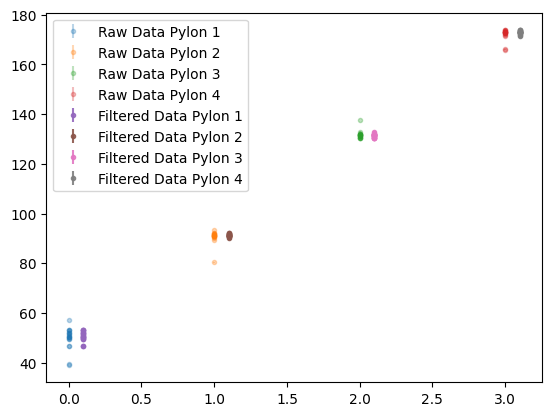

In [22]:
# plot the filtered and raw data errorbar plots together
peak1_all = pylon_no_unc[(pylon_no_unc < 70)]
peak2_all = pylon_no_unc[(pylon_no_unc > 70) & (pylon_no_unc < 110)]
peak3_all = pylon_no_unc[(pylon_no_unc > 110) & (pylon_no_unc < 150)]
peak4_all = pylon_no_unc[(pylon_no_unc > 150)]
plt.errorbar(np.zeros(len(peak1_all)),peak1_all,  yerr=np.ones(len(peak1_all))*0.1, fmt='.', label='Raw Data Pylon 1', alpha=0.3)
plt.errorbar(np.ones(len(peak2_all)),peak2_all,  yerr=np.ones(len(peak2_all))*0.1, fmt='.', label='Raw Data Pylon 2', alpha=0.3)
plt.errorbar(2*np.ones(len(peak3_all)),peak3_all,  yerr=np.ones(len(peak3_all))*0.1, fmt='.', label='Raw Data Pylon 3', alpha=0.3)
plt.errorbar(3*np.ones(len(peak4_all)),peak4_all,  yerr=np.ones(len(peak4_all))*0.1, fmt='.', label='Raw Data Pylon 4', alpha=0.3)

plt.errorbar(0.1 +np.zeros(len(peak1)),peak1,  yerr=np.ones(len(peak1))*0.1, fmt='.', label='Filtered Data Pylon 1', alpha=0.9)
plt.errorbar(0.1 +np.ones(len(peak2)),peak2,  yerr=np.ones(len(peak2))*0.1, fmt='.', label='Filtered Data Pylon 2', alpha=0.9)
plt.errorbar(0.1 +2*np.ones(len(peak3)),peak3,  yerr=np.ones(len(peak3))*0.1, fmt='.', label='Filtered Data Pylon 3', alpha=0.9)
plt.errorbar(0.1 +3*np.ones(len(peak4)),peak4,  yerr=np.ones(len(peak4))*0.1, fmt='.', label='Filtered Data Pylon 4', alpha=0.9)

plt.legend()
plt.show()

In [23]:
# pylon positions with uncertainties
print(f'pylon 1: {mu[0]:.0f} ± {sigma[0]:.0f}')
print(f'pylon 2: {mu[1]:.1f} ± {sigma[1]:.1f}')
print(f'pylon 3: {mu[2]:.1f} ± {sigma[2]:.1f}')
print(f'pylon 4: {mu[3]:.1f} ± {sigma[3]:.1f}')

chi2 = m.fval
print(len(x_fit), m.nfit)
Prob_value = stats.chi2.sf(chi2, len(x_fit)- m.nfit) # The chi2 probability given N_DOF degrees of freedom
p_value = 1 - stats.chi2.cdf(chi2, df=len(x_fit) - len(m.values))
print(f'P-value: {Prob_value}')
print(f'P-value: {p_value}')
print(f'Chi-squared: {chi2}')

pylon 1: 50 ± 3
pylon 2: 91.6 ± 1.1
pylon 3: 131.3 ± 0.9
pylon 4: 173.0 ± 0.7
24 12
P-value: 0.7636091660365656
P-value: 0.7636091660365656
Chi-squared: 8.271013464996631


### Using measurements with uncertainty, determine the four pylon positions.


<ErrorbarContainer object of 3 artists>

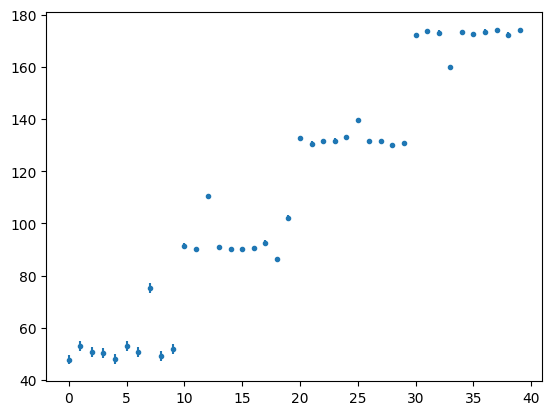

In [24]:
#get dataframe rows where Uncertainty is -1
# print(Ppos[Ppos_unc == -1])
pylons = Ppos[Ppos_unc != -1]
pylon_unc = Ppos_unc[Ppos_unc != -1]
x_min, x_max = 30, 180

plt.errorbar(np.arange(len(pylons)), pylons, yerr=pylon_unc, fmt='.', label='Data with uncertainties')


In [25]:
# splplit the datsets into the four pylons based on position ranges
pylon1 = pylons[(pylons < 70)]
pylon1_unc = pylon_unc[(pylons < 70)]   
pylon2 = pylons[(pylons >= 70) & (pylons < 110)]
pylon2_unc = pylon_unc[(pylons >= 70) & (pylons < 110)]
pylon3 = pylons[(pylons >= 110) & (pylons < 150)]
pylon3_unc = pylon_unc[(pylons >= 110) & (pylons < 150)]
pylon4 = pylons[(pylons >= 150)]
pylon4_unc = pylon_unc[(pylons >= 150)]

p1 = np.average(pylon1, weights=1/pylon1_unc**2)
p2 = np.average(pylon2, weights=1/pylon2_unc**2)
p3 = np.average(pylon3, weights=1/pylon3_unc**2)
p4 = np.average(pylon4, weights=1/pylon4_unc**2)

def weighted_std(values, weights):
    average = np.average(values, weights=weights)
    variance = np.average((values-average)**2, weights=weights)
    return np.sqrt(variance)

s1 = weighted_std(pylon1, weights=1/pylon1_unc**2)
s2 = weighted_std(pylon2, weights=1/pylon2_unc**2)
s3 = weighted_std(pylon3, weights=1/pylon3_unc**2)
s4 = weighted_std(pylon4, weights=1/pylon4_unc**2)

print(f'Pylon 1: Mean = {p1:.2f}, Std = {s1:.2f}')
print(f'Pylon 2: Mean = {p2:.2f}, Std = {s2:.2f}')
print(f'Pylon 3: Mean = {p3:.2f}, Std = {s3:.2f}')
print(f'Pylon 4: Mean = {p4:.2f}, Std = {s4:.2f}')

Pylon 1: Mean = 50.57, Std = 1.82
Pylon 2: Mean = 90.53, Std = 3.90
Pylon 3: Mean = 130.02, Std = 7.23
Pylon 4: Mean = 171.44, Std = 4.54


In [26]:
def chauvenet(data, data_unc):
    if len(data) <= 1:
        return data
    lendata = len(data)
    while True:
        mean = np.average(data, weights=1/data_unc**2)
        std = np.std(data, ddof=1)
        n = len(data)
        threshold = 1 / (2 * n)
        filtered = []
        filtered_unc = []
        for x in data:
            z = abs(x - mean) / std
            prob = 2 * (1 - stats.norm.cdf(z))
            if prob > threshold:
                filtered.append(x)
                filtered_unc.append(data_unc[np.where(data == x)[0][0]])

        data = np.array(filtered)
        data_unc = np.array(filtered_unc)
        if len(data) == lendata:
            break
        lendata = len(data)
    return data, data_unc

pylon1, pylon1_unc = chauvenet(pylon1, pylon1_unc)
pylon2, pylon2_unc = chauvenet(pylon2, pylon2_unc)
pylon3, pylon3_unc = chauvenet(pylon3, pylon3_unc)
pylon4, pylon4_unc = chauvenet(pylon4, pylon4_unc)

<ErrorbarContainer object of 3 artists>

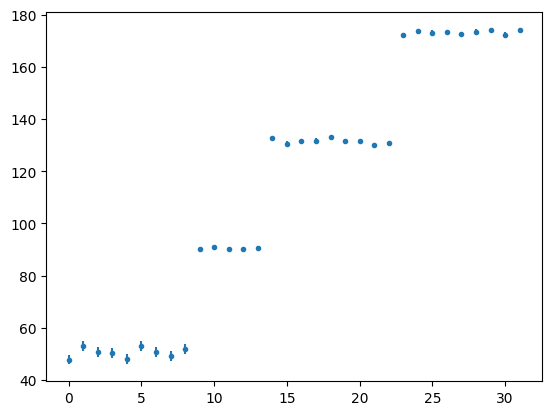

In [27]:
pylon_vetted = np.concatenate([pylon1, pylon2, pylon3, pylon4])
pylon_unc_vetted = np.concatenate([pylon1_unc, pylon2_unc, pylon3_unc, pylon4_unc])
plt.errorbar(np.arange(len(pylon_vetted)), pylon_vetted, yerr=pylon_unc_vetted, fmt='.', label='Vetted Data with uncertainties')

In [28]:
p1 = np.average(pylon1, weights=1/pylon1_unc**2)
p2 = np.average(pylon2, weights=1/pylon2_unc**2)
p3 = np.average(pylon3, weights=1/pylon3_unc**2)
p4 = np.average(pylon4, weights=1/pylon4_unc**2)

def weighted_std(values, weights):
    average = np.average(values, weights=weights)
    variance = np.average((values-average)**2, weights=weights)
    return np.sqrt(variance)

s1 = weighted_std(pylon1, weights=1/pylon1_unc**2)
s2 = weighted_std(pylon2, weights=1/pylon2_unc**2)
s3 = weighted_std(pylon3, weights=1/pylon3_unc**2)
s4 = weighted_std(pylon4, weights=1/pylon4_unc**2)

print(f'Pylon 1: Mean = {p1:.2f}, Std = {s1:.2f}')
print(f'Pylon 2: Mean = {p2:.2f}, Std = {s2:.2f}')
print(f'Pylon 3: Mean = {p3:.2f}, Std = {s3:.2f}')
print(f'Pylon 4: Mean = {p4:.2f}, Std = {s4:.2f}')

Pylon 1: Mean = 50.57, Std = 1.82
Pylon 2: Mean = 90.43, Std = 0.32
Pylon 3: Mean = 131.58, Std = 0.91
Pylon 4: Mean = 173.19, Std = 0.67


### Combine the two measurement groups. Do they match each other?


In [29]:
# the z value for each pylon value is
for i in range(4):
    z = abs(peaks_mean[i] - [p1, p2, p3, p4][i]) / np.sqrt(peaks_std[i]**2 + [s1, s2, s3, s4][i]**2)
    print(f'Pylon {i+1}: z = {z:.3f}, p = {stats.norm.sf(z)*2:.4f}')

Pylon 1: z = 0.068, p = 0.9457
Pylon 2: z = 1.429, p = 0.1529
Pylon 3: z = 0.097, p = 0.9228
Pylon 4: z = 0.274, p = 0.7843


### Test if the four measured pylon positions are equidistant.

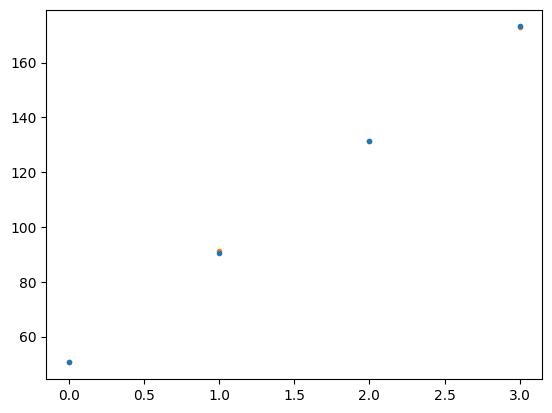

In [30]:
plt.errorbar(np.arange(4), [p1, p2, p3, p4], fmt='.', label='Filtered Data Means with uncertainties')
plt.plot(np.arange(4), [np.mean(peak1), np.mean(peak2), np.mean(peak3), np.mean(peak4)], '.', label='Fit Means without uncertainties')
plt.show()

Fitted intercept a: 7.92 ± 0.87
Fitted slope b (spacing): 41.28 ± 0.35
Chi-squared: 0.68
Degrees of freedom: 2
Reduced chi-squared: 0.34
P-value: 0.7105


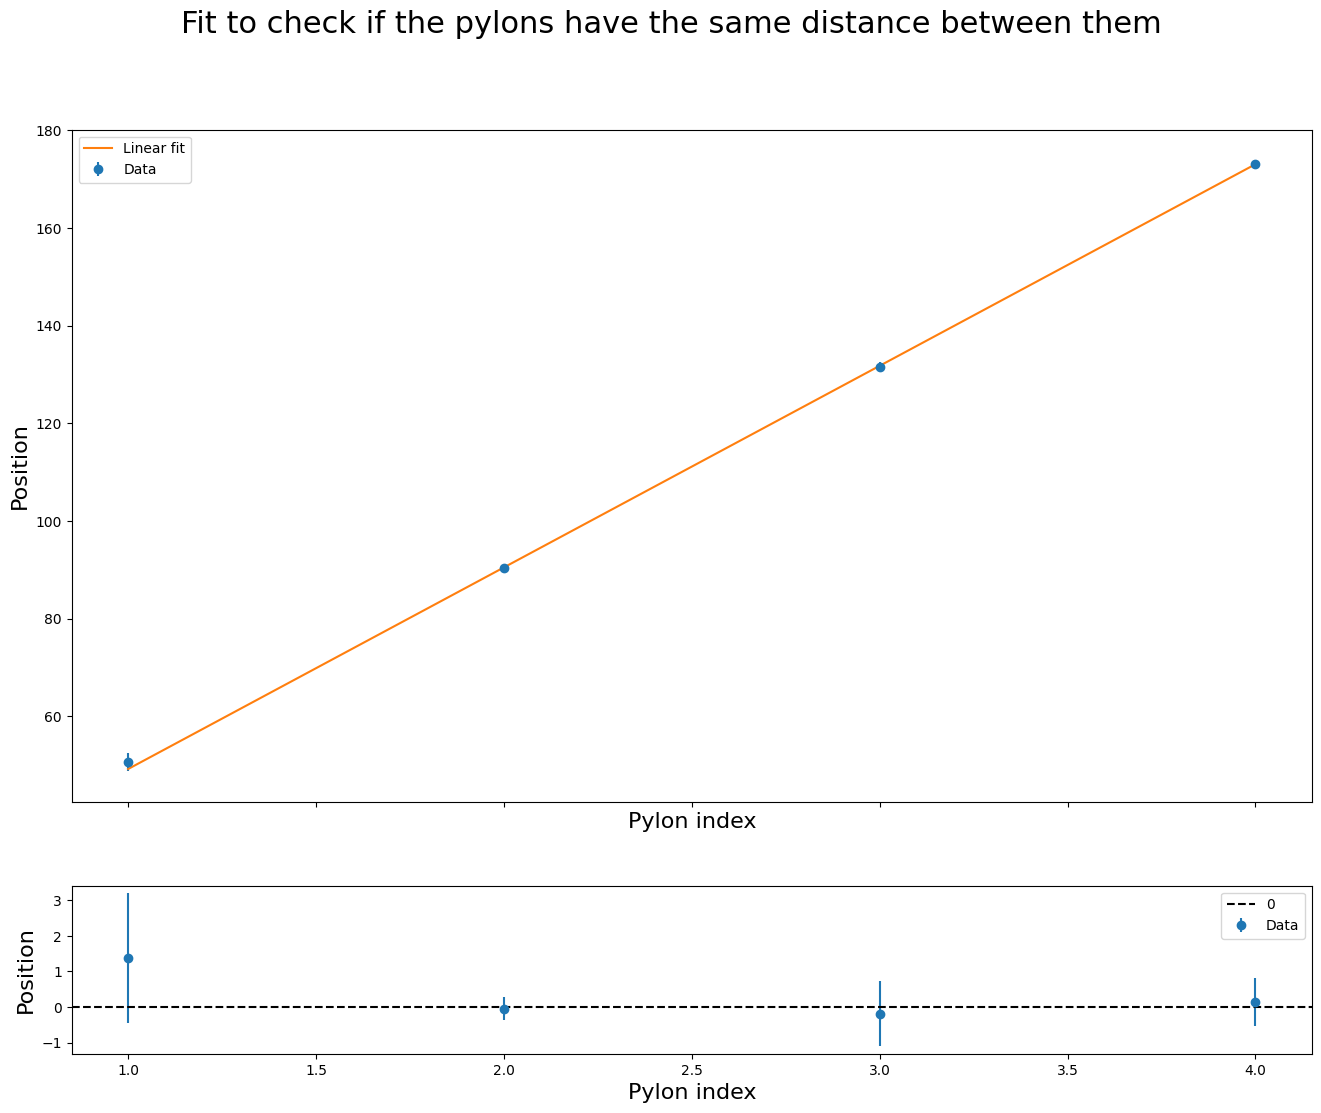

In [31]:
xx = np.array([1,2,3,4])

# Positions and uncertainties from measurements with uncertainties
yy = np.array([p1, p2, p3, p4])
yerr = np.array([s1, s2, s3, s4])

# Define linear fit function for equidistant positions
def linear(x, a, b):
    return a + b * x

# Perform least squares fit
cfit = cost.LeastSquares(xx, yy, yerr, linear)
m = Minuit(cfit, a=50, b=40)
m.migrad()

# Print fit results
print(f"Fitted intercept a: {m.values['a']:.2f} ± {m.errors['a']:.2f}")
print(f"Fitted slope b (spacing): {m.values['b']:.2f} ± {m.errors['b']:.2f}")
print(f"Chi-squared: {m.fval:.2f}")
print(f"Degrees of freedom: {len(xx) - len(m.values)}")
print(f"Reduced chi-squared: {m.fval / (len(xx) - len(m.values)):.2f}")
p_value = stats.chi2.sf(m.fval, len(xx) - len(m.values))
print(f"P-value: {p_value:.4f}")

# Plot
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(16, 12),
                       gridspec_kw={'height_ratios':[4,1]}, sharex=True)
fig.suptitle('Fit to check if the pylons have the same distance between them', fontsize=22)
# Plot the fit
ax[0].errorbar(xx, yy, yerr=yerr, fmt='o', label='Data')
ax[0].plot(xx, linear(xx, *m.values), label='Linear fit')
ax[0].set_xlabel('Pylon index', fontsize=16 )
ax[0].set_ylabel('Position', fontsize=16)
ax[0].legend()


ax[1].errorbar(xx , yy - linear(xx, *m.values), yerr=yerr, fmt='o', label='Data')
# ax[1].plot(xx, linear(xx, *m.values), label='Linear fit')
ax[1].set_xlabel('Pylon index', fontsize=16)
ax[1].set_ylabel('Position', fontsize=16)
ax[1].axhline(0, color='k', linestyle='--', label=0)
# ax[1].axhline(+sigma_t, color='k', linestyle=':')
# ax[1].axhline(-sigma_t, color='k', linestyle=':')
ax[1].legend()

plt.show()

# 3 montecarlo/simulation

## Circles A and B

### 2D fraction overlap

In [96]:
# Generate uniformly distributed points in a 2D circle
def circ_generetor(R,N,x0,y0):
    theta = np.random.uniform(0, 2 * np.pi, N)
    r = np.sqrt(np.random.uniform(0, 1, N))*R
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x + x0, y + y0

def circ_from_lattice(R,N,x0,y0):
    step = 4/(np.pi*np.sqrt(N/2))
    X,Y = np.mgrid[-R:R+step/2:step*R, -R:R+R*step/2:step*R]
    X = X.flatten()
    Y = Y.flatten()

    mask = (X**2 + Y**2 < R**2)
    X = X[mask]
    Y = Y[mask]

    return X+x0, Y+y0

# calcluate overlap with a circle
def overlap_finder(x,y,R,x0,y0):
    mask = ((x-x0)**2 + (y-y0)**2 < R**2)

    x_new = x[mask]
    y_new = y[mask]

    return x_new, y_new
    

-5.997821750428613 5.997316280791403


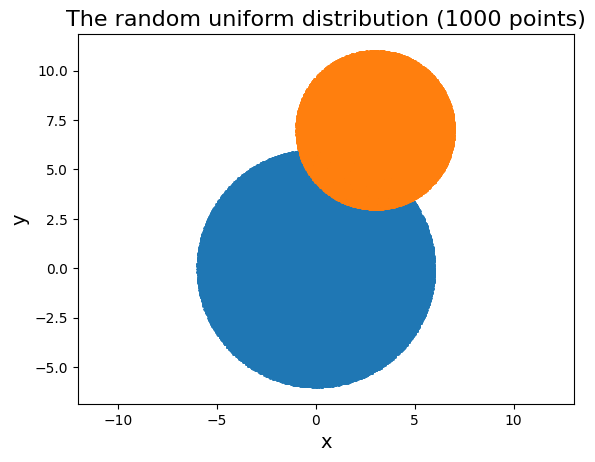

In [ ]:
# Plot the points
x1, y1 = circ_generetor(6,1000,0,0)
x2, y2 = circ_generetor(4,1000,3,7)
print(min(x1), max(x1))

plt.scatter(x1, y1, s=1)
plt.scatter(x2, y2, s=1)
plt.axis('equal')
plt.title('The random uniform distribution (1000 points)', fontsize=16)
plt.xlabel('x', fontsize= 14)
plt.ylabel('y', fontsize= 14)
plt.show()

96892 -5.965835397915976 5.991775331492599


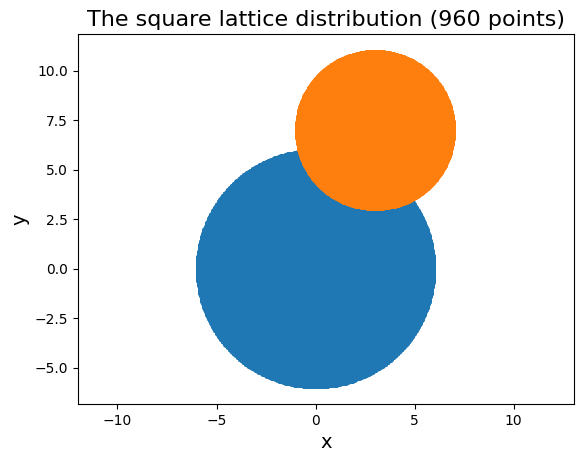

In [ ]:
# Plot the points
X1, Y1 = circ_from_lattice(6,1000,0,0)
X2, Y2 = circ_from_lattice(4,1000,3,7)
print(len(X1), min(X1), max(X1))
# plt.figure(figsize=[12,9],dpi=500)
plt.scatter(X1, Y1, s=1)
plt.scatter(X2, Y2, s=1)
plt.axis('equal')
plt.title('The square lattice distribution (960 points)', fontsize=16)
plt.xlabel('x', fontsize= 14)
plt.ylabel('y', fontsize= 14)
# plt.plot([-6,-6,6,6], [-6,6,6,-6])

plt.show()

<!-- ### 4D version -->

In [107]:
# overlap is:
x1_overlap, y1_overlap = overlap_finder(x1,y1, 4,3,7)
x2_overlap, y2_overlap = overlap_finder(x2,y2, 6,0,0)
X1_overlap, Y1_overlap = overlap_finder(X1,Y1, 4,3,7)
X2_overlap, Y2_overlap = overlap_finder(X2,Y2, 6,0,0)
sanity = [len(overlap_finder(x1,y1, 6,0,0)[0]), len(overlap_finder(x2,y2, 4,3,7)[0]), len(overlap_finder(X1,Y1, 6,0,0)[0]), len(overlap_finder(X2,Y2, 4,3,7)[0])]

print(len(x1_overlap)/len(x1))
print(len(x2_overlap)/len(x2))
print(len(X1_overlap)/len(X1))
print(len(X2_overlap)/len(X2))
print(np.array(sanity)/np.array([len(x1), len(x2), len(X1), len(X2)]))

0.09057
0.20443
0.09098790405812657
0.2043925195062544
[1. 1. 1. 1.]


### 4D version

In [260]:
# Generate uniformly distributed points in a 4D circle
def circ_generetor_4d(R,N,x0):
    result = np.zeros((4,N))
    counter = 0
    numbers_generated = 0

    while counter < N:
        test = np.random.uniform(-R,R, (4, N - counter))
        numbers_generated += N-counter
        x1 = test[0,:]
        x2 = test[1,:]
        x3 = test[2,:]
        x4 = test[3,:]
        mask = (x1**2 + x2**2 + x3**2 + x4**2 < R**2)
        x1 = x1[mask]
        x2 = x2[mask]
        x3 = x3[mask]
        x4 = x4[mask]

        if len(x1>0):
            result[0,counter:counter+len(x1)] = x1
            result[1,counter:counter+len(x1)] = x2
            result[2,counter:counter+len(x1)] = x3
            result[3,counter:counter+len(x1)] = x4
            counter += len(x1)

    for i in range(4):
        result[i,:] += x0[i]
    return result



def circ_from_lattice_4d(R,N,x0):
    step = (N)**(-1/4)
    x1,x2,x3,x4 = np.mgrid[-R:R+step/2:step*R, -R:R+R*step/2:step*R, -R:R+R*step/2:step*R, -R:R+R*step/2:step*R]
    x1 = x1.flatten()
    x2 = x2.flatten()
    x3 = x3.flatten()
    x4 = x4.flatten()
    
    mask = (x1**2 +x2**2 + x3**2 +x4**2 < R**2)
    x1 = x1[mask]
    x2 = x2[mask]
    x3 = x3[mask]
    x4 = x4[mask]
    
    x =np.zeros((4,len(x1)))
    x[0,:] = x1 + x0[0]
    x[1,:] = x2 + x0[1]
    x[2,:] = x3 + x0[2]
    x[3,:] = x4 + x0[3]

    return x

# calcluate overlap with a circle
def overlap_finder_4d(x,R,x0):
    x_test = x.copy()
    for i in range(4):
        x_test[i,:] -= x0[i]
        
    mask = (x_test[0,:]**2 +x_test[1,:]**2 + x_test[2,:]**2 + x_test[3,:]**2 < R**2)

    x_new = np.zeros((4,len(x[0][mask])))
    for i in range(4):
        x_new[i,:] = x[i][mask]

    return x_new

In [270]:
c1 = [0,0,0,0]
c2 = [3,7,-1,2]

x1_rand =    circ_generetor_4d(6,100000,c1)
x2_rand =    circ_generetor_4d(4,100000,c2)
x1_latt = circ_from_lattice_4d(6,21000,c1)
x2_latt = circ_from_lattice_4d(4,21000,c2)
print(len(x1_latt[0]))
print(np.mean(x2_rand, axis=1))
print(np.mean(x2_latt, axis=1))

103130
[ 2.99715958  6.99747312 -0.99944579  2.00560299]
[ 2.99777902  6.99777902 -1.00222098  1.99777902]


In [271]:
xr_12 = overlap_finder_4d(x1_rand,4,c2)
xr_21 = overlap_finder_4d(x2_rand,6,c1)

xl_12 = overlap_finder_4d(x1_latt,4,c2)
xl_21 = overlap_finder_4d(x2_latt,6,c1)


print(f'AB random: {len(xr_12[0])}; \t fraction: {len(xr_12[0])/len(x1_rand[0]):.4f}')
print(f'BA random: {len(xr_21[0])}; \t fraction: {len(xr_21[0])/len(x2_rand[0]):.4f}')
print(f'AB lattice:{len(xl_12[0])}; \t fraction: {len(xl_12[0])/len(x1_latt[0]):.4f}')
print(f'AB lattice:{len(xl_21[0])}; \t fraction: {len(xl_21[0])/len(x2_latt[0]):.4f}')

AB random: 1512; 	 fraction: 0.0151
BA random: 7411; 	 fraction: 0.0741
AB lattice:1510; 	 fraction: 0.0146
AB lattice:7656; 	 fraction: 0.0742


## Explosion

### r

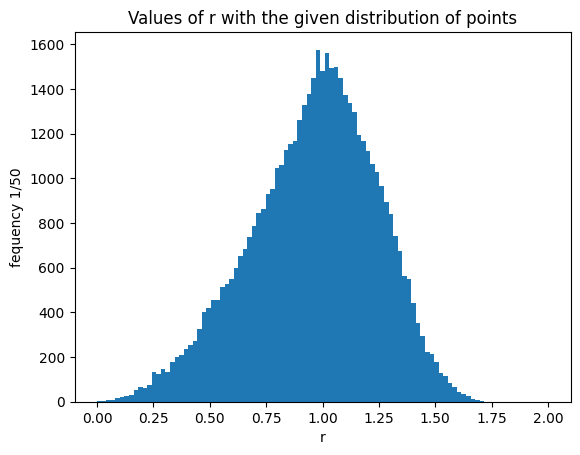

In [284]:
datapoints = np.random.uniform(-1,1, (3,50000))

r = np.sqrt(np.sum(datapoints**2, axis=0))
Bins= np.linspace(0,2,100)
plt.hist(r, bins=Bins)
plt.xlabel('r')
plt.ylabel('fequency 1/50')
plt.title('Values of r with the given distribution of points')
plt.show()

### $\theta$ and $\phi$

In [291]:
mask1 = (r < 1)

x = datapoints[0,:][mask1].copy()
y = datapoints[1,:][mask1].copy()
z = datapoints[2,:][mask1].copy()

mask2 = (z > 0)

x = x[mask2]
y = y[mask2]
z = z[mask2]

r_r = np.sqrt(x**2 + y**2 + z**2)


In [294]:
# Bins= np.linspace(0,1,100)
# plt.hist(r_r, bins=Bins)
# plt.xlabel('r')
# plt.ylabel('fequency 1/100')
# plt.title('Values of r with the given distribution of points')
# plt.show()

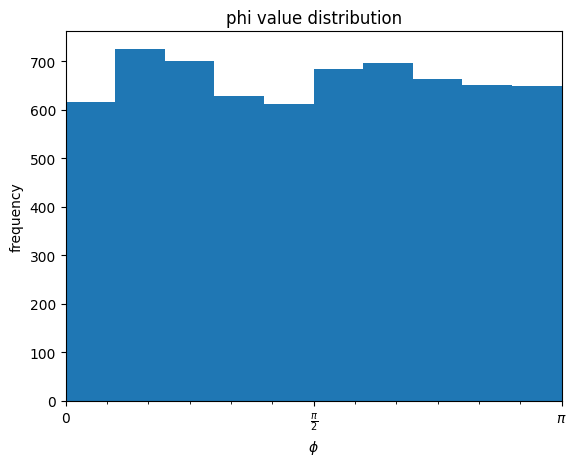

In [317]:
theta = np.arctan2(np.sqrt(x*x + y*y),z)
phi   = np.arctan2(y,x)

plt.xlim(0,np.pi)
plt.xticks()
plt.hist(phi, bins=np.linspace(0,np.pi,11))
plt.title('phi value distribution')
plt.xlabel('$\phi$')
plt.ylabel('frequency')
ax = plt.gca()
ax.xaxis.set_major_locator(plt.MultipleLocator(np.pi / 2))
ax.xaxis.set_minor_locator(plt.MultipleLocator(np.pi / 12))
ax.xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))
plt.show()

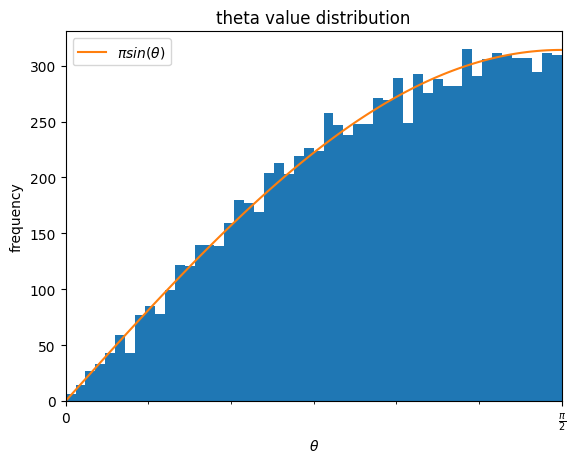

In [473]:
plt.xlim(0,np.pi/2)
plt.xticks()
plt.hist(theta[:10000], bins=np.linspace(0,np.pi,101))
plt.plot(np.linspace(0,np.pi/2,101), np.pi*len(theta[:10000])*np.sin(np.linspace(0,np.pi/2,101))/100, label='$\pi sin(\\theta)$')
plt.title('theta value distribution')
plt.xlabel('$\\theta$')
plt.ylabel('frequency')
ax = plt.gca()
ax.xaxis.set_major_locator(plt.MultipleLocator(np.pi / 2))
ax.xaxis.set_minor_locator(plt.MultipleLocator(np.pi / 12))
ax.xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))
plt.legend()
plt.show()

### the equation f

In [487]:
v_0 = 100
def f(x):
    return x*x*np.exp(-x/v_0)/(v_0*v_0)

In [500]:
N_points = 10000
x_accepted = np.zeros(N_points)
y_accepted = np.zeros(N_points)
Ntry = 0
for i in range(N_points):
    while True:
        Ntry += 1
        x = -4000*np.log(np.random.uniform(0., 1))
        y = np.random.uniform(0, 10)
        if (y < f(x) ):
            break      
    x_accepted[i] = x
    y_accepted[i] = y


print(Ntry)



2131854


0.0 9.90049833749168e-05


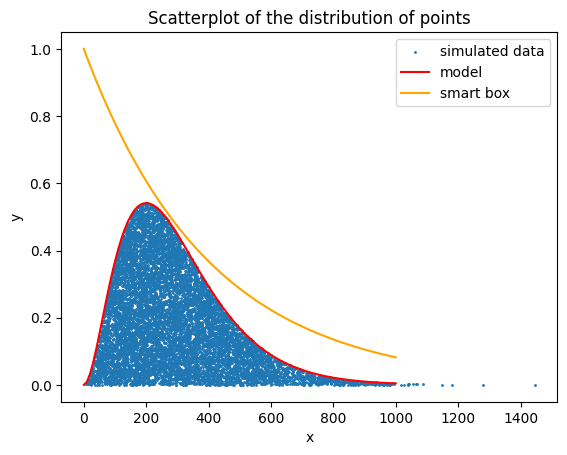

In [529]:
print(f(0), f(1))

xx = np.linspace(0.01,1000,100)
plt.scatter(x_accepted, y_accepted, s=1, label='simulated data')
plt.plot(xx, f(xx), color= 'red', label= 'model')
plt.plot(xx, np.exp(-xx/400), color= 'orange', label= 'smart box')
plt.title('Scatterplot of the distribution of points')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [502]:
theta10k = theta[:10000]
v_10k    = x_accepted
g = 9.82

Text(0, 0.5, 'frequency (1/1000)')

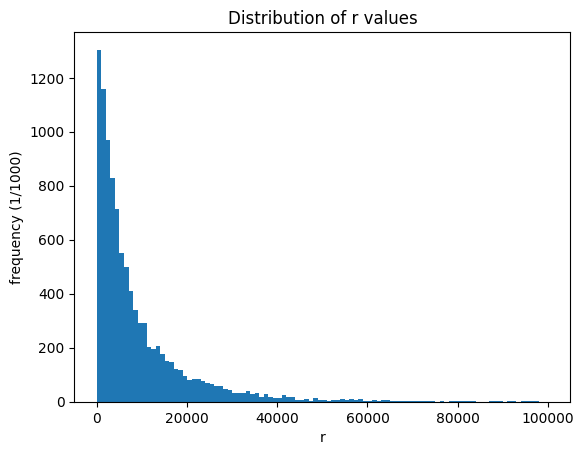

In [530]:
m_r = np.sin(theta10k)*v_10k**2/g

Bins = np.linspace(0,1.e5,101)
plt.hist(m_r, bins=Bins, label='m(r)')
# plt.yscale('log')
plt.title('Distribution of r values')
plt.xlabel('r')
plt.ylabel('frequency (1/1000)')

# Statistical test

### make and plot the results

In [627]:
def roll_dice(rolls, fake_die = False, selecter = 0, dice_per_roll = 25, sides_per_die = 6):
    if fake_die == False:
        return np.random.randint(1,sides_per_die+1,(rolls,dice_per_roll)), 0
    elif fake_die == True:
        vals = np.random.randint(1,sides_per_die+1,(rolls,dice_per_roll))
        fake_locs = np.random.randint(1, dice_per_roll, rolls)
        if selecter == 0:
            selecter = np.random.randint(1,7) 
        for i in range(rolls):
            vals[i,fake_locs[i]] = selecter
        return vals, selecter
    else:
        print('error')
        return


def dice_roller_blinder(rolls = 200, fake_die_random = np.random.randint(2), selecter = np.random.randint(1,7), dice_per_roll = 25):
    a, fake= roll_dice(rolls, fake_die= False, selecter = selecter, dice_per_roll = dice_per_roll, sides_per_die = 6)
    b, fake = roll_dice(rolls, fake_die= True,  selecter = selecter, dice_per_roll = dice_per_roll, sides_per_die = 6)
    
    if fake_die_random == 0:
        return a,b, [fake, fake_die_random]
    else:
        return b,a, [fake, fake_die_random]

def freq(a, n):
    return sum(sum(a==n))


In [628]:
a, b, fake = dice_roller_blinder( fake_die_random = np.random.randint(2), selecter = np.random.randint(1,7))


[1 2 3 4 5 6]
[6, 0]


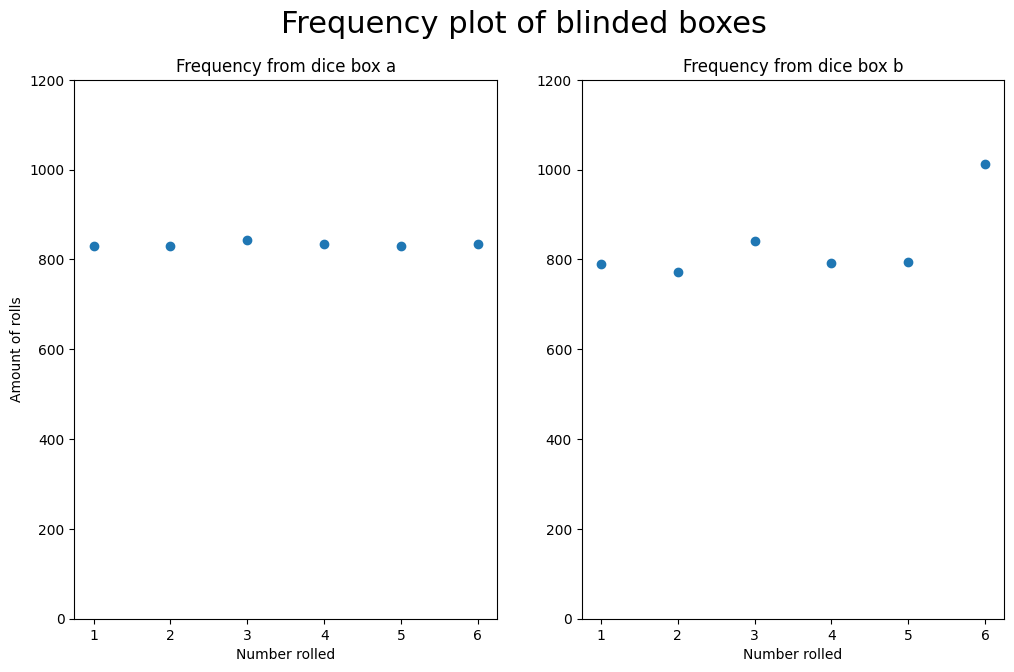

In [657]:
a, b, fake = dice_roller_blinder( fake_die_random = np.random.randint(2), selecter = np.random.randint(1,7))

a_freq=np.zeros(6)
b_freq=np.zeros(6)
num = np.arange(1,7)
print(num)
print(fake)
for i in range(6):
    a_freq[i] = freq(a,i+1)
    b_freq[i] = freq(b,i+1)

# Plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 7))
fig.suptitle('Frequency plot of blinded boxes', fontsize=22)
# Plot the fit
ax[0].plot(num, a_freq,'o', label='Data')
ax[0].set_title('Frequency from dice box a')
ax[0].set_ylim(0,1200)
ax[0].set_ylabel('Amount of rolls')
ax[0].set_xlabel('Number rolled')

ax[1].plot(num, b_freq,'o', label='Data')
ax[1].set_title('Frequency from dice box b')
ax[1].set_ylim(0,1200)
ax[1].set_xlabel('Number rolled')

plt.show()

In [658]:

def test1(x,c):
    return np.ones_like(x)*c


# Fit to a_freq
y_err_a = np.sqrt(a_freq)
cfit_a = cost.LeastSquares(num, a_freq, y_err_a, test1)
m_a = Minuit(cfit_a, c=800)
m_a.migrad()
p_a = chi2.sf(m_a.fval, 5 )

print("Fit to a_freq:")
print(f"Constant c: {m_a.values['c']:.2f} ± {m_a.errors['c']:.2f}")
print(f"Chi-squared: {m_a.fval:.2f}")
print(f"Reduced chi-squared: {m_a.fval / (len(num) - len(m_a.values)):.2f}")
print(f'p = {p_a:.3f}')

# Fit to b_freq
y_err_b = np.sqrt(b_freq)
cfit_b = cost.LeastSquares(num, b_freq, y_err_b, test1)
m_b = Minuit(cfit_b, c=800)
m_b.migrad()
p_b = chi2.sf(m_b.fval, 5 )


print("\nFit to b_freq:")
print(f"Constant c: {m_b.values['c']:.2f} ± {m_b.errors['c']:.2f}")
print(f"Chi-squared: {m_b.fval:.2f}")
print(f"Reduced chi-squared: {m_b.fval / (len(num) - len(m_b.values)):.2f}")
print(f'p = {p_b:.3f}')


Fit to a_freq:
Constant c: 833.30 ± 11.78
Chi-squared: 0.21
Reduced chi-squared: 0.04
p = 0.999

Fit to b_freq:
Constant c: 826.13 ± 11.73
Chi-squared: 43.20
Reduced chi-squared: 8.64
p = 0.000


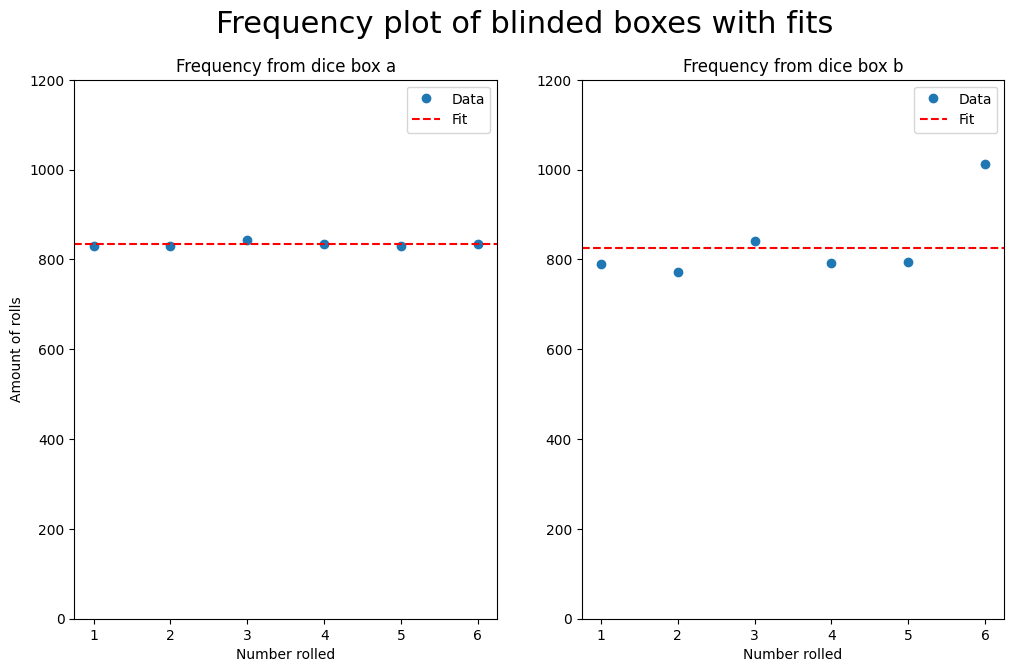

In [694]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 7))
fig.suptitle('Frequency plot of blinded boxes with fits', fontsize=22)

ax[0].plot(num, a_freq, 'o', label='Data')
ax[0].axhline(y=m_a.values['c'], color='red', linestyle='--', label='Fit')
ax[0].set_title('Frequency from dice box a')
ax[0].set_ylim(0, 1200)
ax[0].set_ylabel('Amount of rolls')
ax[0].set_xlabel('Number rolled')
ax[0].legend()

ax[1].plot(num, b_freq, 'o', label='Data')
ax[1].axhline(y=m_b.values['c'], color='red', linestyle='--', label='Fit')
ax[1].set_title('Frequency from dice box b')
ax[1].set_ylim(0, 1200)
ax[1].set_xlabel('Number rolled')
ax[1].legend()

plt.show()

In [659]:
print(np.std(a_freq))
print(np.std(b_freq))

5.3748384988657
83.1177210681065


In [706]:
def test_machine1(rounds=150, fake_die = False):
    test_results = np.zeros((100,2))
    for i in range(100):
        q , j = roll_dice(rolls = rounds, fake_die=fake_die, selecter = np.random.randint(1,7))
        q_freq = np.zeros(6)
        for h in range(6):
            q_freq[h] = freq(q,h +1)
        test_results[i,1] = np.std(q_freq)

        y_err_q = np.sqrt(q_freq)
        cfit_q = cost.LeastSquares(num, q_freq, y_err_q, test1)
        m_q = Minuit(cfit_q, c=800)
        m_q.migrad()
        test_results[i,0] = chi2.sf(m_q.fval, 5 )
    return test_results

d0 = test_machine1()
d1 = test_machine1(fake_die=True)


[0.04095616 0.06380497 0.01542555 0.05958494 0.01411201 0.06340066
 0.01299665 0.01358039 0.05287143 0.01243294 0.22343776 0.02283183
 0.02870851 0.02022949 0.05836214 0.01855499 0.36104074 0.01853439
 0.01354653 0.03493971 0.01445383 0.01095559 0.01468688 0.05716914
 0.01054232 0.01397795]


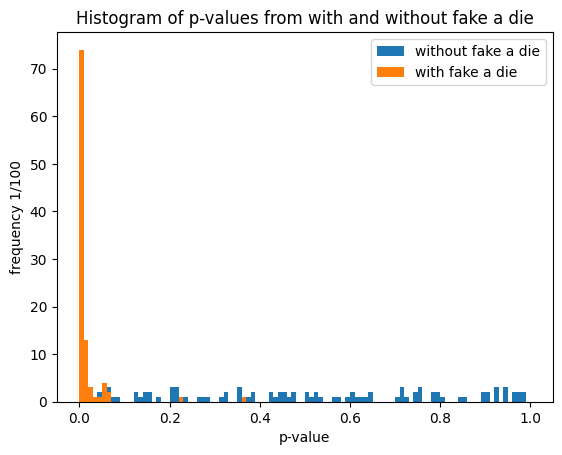

In [785]:
d1 = test_machine1(rounds= 100, fake_die=True)


Bins = np.linspace(0,1,101)
plt.hist(d0[:,0], bins=Bins, label='without fake a die')
plt.hist(d1[:,0], bins=Bins, label='with fake a die')
# print(min(d0[:,0]), max(d1[:,0]))
# print(d0[:,0][(d0[:,0] < 0.01)])
print(d1[:,0][(d1[:,0] > 0.01)])
plt.xlabel('p-value')
plt.ylabel('frequency 1/100')
plt.title('Histogram of p-values from with and without fake a die')
plt.legend()
plt.show()